C:\Users\knut1\AppData\Local\Temp\ipykernel_31408\3443410888.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr8, mode="RGB").save(path)
C:\Users\knut1\AppData\Local\Temp\ipykernel_31408\3443410888.py:18: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr8, mode="L").save(path)
C:\Users\knut1\AppData\Local\Temp\ipykernel_31408\3443410888.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((clip01(frame)*255).astype(np.uint8), mode="RGB")


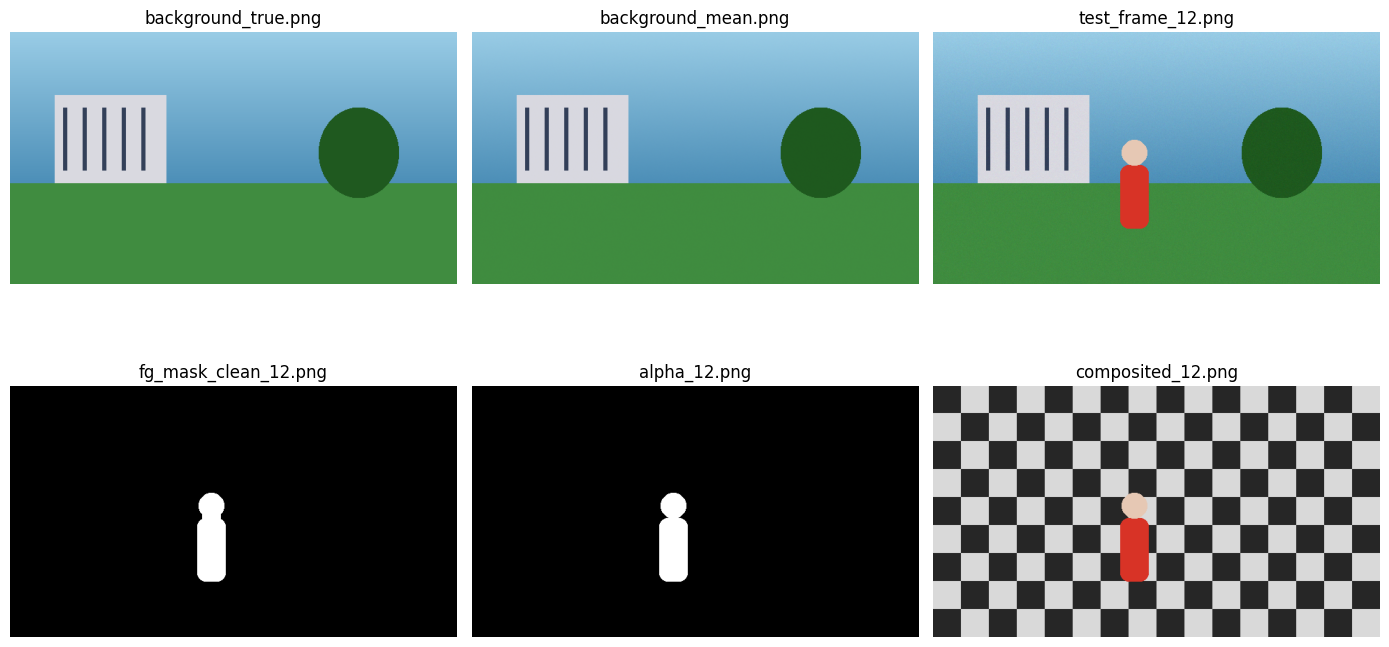

'/mnt/data/ex3_5_difference_keying_outputs.zip'

In [5]:
import os, shutil, zipfile, numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

out_dir = "/mnt/data/ex3_5_difference_keying"
if os.path.exists(out_dir):
    shutil.rmtree(out_dir)
os.makedirs(out_dir, exist_ok=True)

def clip01(x): return np.clip(x, 0.0, 1.0)

def save_img(path, arr01):
    arr8 = (clip01(arr01)*255.0 + 0.5).astype(np.uint8)
    Image.fromarray(arr8, mode="RGB").save(path)

def save_gray(path, arr01):
    arr8 = (clip01(arr01)*255.0 + 0.5).astype(np.uint8)
    Image.fromarray(arr8, mode="L").save(path)

# --- Synthetic background ---
H, W = 360, 640
bg = np.zeros((H, W, 3), dtype=np.float32)
y = np.linspace(0, 1, H, dtype=np.float32)[:, None]  # (H,1)
bg[..., 2] = 0.9 - 0.3*y   # blue
bg[..., 1] = 0.8 - 0.4*y   # green
bg[..., 0] = 0.6 - 0.5*y   # red

# ground region
bg[int(H*0.6):, :, :] = np.array([0.25, 0.55, 0.25], dtype=np.float32)

# building rectangle
bg[int(H*0.25):int(H*0.60), int(W*0.10):int(W*0.35), :] = np.array([0.85,0.85,0.88], np.float32)
# window stripes
for k in range(5):
    x0 = int(W*0.12) + k*28
    bg[int(H*0.30):int(H*0.55), x0:x0+6, :] = np.array([0.2,0.25,0.35], np.float32)

# tree-ish blob
yy, xx = np.mgrid[0:H, 0:W]
tree = ((xx - int(W*0.78))**2/(W*0.09)**2 + (yy - int(H*0.48))**2/(H*0.18)**2) < 1.0
bg[tree] = np.array([0.12,0.35,0.12], np.float32)

save_img(os.path.join(out_dir, "background_true.png"), bg)

# --- Training sequence (empty) ---
rng = np.random.default_rng(7)

def add_sensor_noise(img, sigma=0.01):
    return clip01(img + rng.normal(0.0, sigma, size=img.shape).astype(np.float32))

def add_flicker(img, amp=0.015):
    f = 1.0 + float(rng.normal(0.0, amp))
    return clip01(img * f)

n_train = 30
train = np.stack([add_sensor_noise(add_flicker(bg), sigma=0.01) for _ in range(n_train)], axis=0)
mu = train.mean(axis=0)
var = train.var(axis=0) + 1e-6

save_img(os.path.join(out_dir, "background_mean.png"), mu)
var_vis = var.mean(axis=2)
var_vis_norm = var_vis / (np.percentile(var_vis, 99) + 1e-12)
save_gray(os.path.join(out_dir, "background_var_vis.png"), clip01(var_vis_norm*2.0))

# --- Test frames with moving person blob ---
def draw_person(frame, cx, cy, scale=1.0, color=(0.85,0.20,0.15)):
    img = Image.fromarray((clip01(frame)*255).astype(np.uint8), mode="RGB")
    d = ImageDraw.Draw(img, "RGBA")
    body_w = int(40*scale); body_h = int(90*scale); head_r = int(18*scale)
    d.rounded_rectangle([cx-body_w//2, cy-body_h, cx+body_w//2, cy], radius=int(12*scale),
                        fill=(int(color[0]*255), int(color[1]*255), int(color[2]*255), 255))
    d.ellipse([cx-head_r, cy-body_h-head_r*2, cx+head_r, cy-body_h], fill=(230,200,180,255))
    return np.asarray(img).astype(np.float32)/255.0

n_test = 25
test_frames = []
true_masks = []
for t in range(n_test):
    base = add_sensor_noise(add_flicker(bg), sigma=0.01)
    cx = int(W*0.10 + t*(W*0.70/(n_test-1)))
    cy = int(H*0.78)
    fr = draw_person(base, cx, cy, scale=1.0)
    mask = (np.abs(fr - base) > 1e-4).any(axis=2).astype(np.float32)
    test_frames.append(fr); true_masks.append(mask)

test_frames = np.stack(test_frames, axis=0)
true_masks = np.stack(true_masks, axis=0)

save_img(os.path.join(out_dir, "test_frame_12.png"), test_frames[12])
save_gray(os.path.join(out_dir, "true_mask_12.png"), true_masks[12])

# --- Difference keying ---
def difference_key(frame, mu, var, k=3.0):
    z2 = ((frame - mu)**2) / var
    score = z2.sum(axis=2)
    thr = 3.0*(k**2)
    fg = (score > thr).astype(np.float32)
    return fg, score, thr

# Morphology without external libs
def _shift2d(mask, dy, dx):
    out = np.roll(np.roll(mask, dy, axis=0), dx, axis=1)
    # clamp edges (avoid wrap artifacts)
    if dy < 0: out[dy:] = mask[dy:]
    if dy > 0: out[:dy] = mask[:dy]
    if dx < 0: out[:, dx:] = mask[:, dx:]
    if dx > 0: out[:, :dx] = mask[:, :dx]
    return out

def binary_erode(mask, radius=2):
    out = np.ones_like(mask)
    r = radius
    for dy in range(-r, r+1):
        for dx in range(-r, r+1):
            out = np.minimum(out, _shift2d(mask, dy, dx))
    return out

def binary_dilate(mask, radius=2):
    out = np.zeros_like(mask)
    r = radius
    for dy in range(-r, r+1):
        for dx in range(-r, r+1):
            out = np.maximum(out, _shift2d(mask, dy, dx))
    return out

def opening(mask, r=2):
    return binary_dilate(binary_erode(mask, r), r)

def closing(mask, r=2):
    return binary_erode(binary_dilate(mask, r), r)

# New background (checkerboard)
cb = np.zeros((H, W, 3), np.float32)
tile = 40
for y0 in range(0, H, tile):
    for x0 in range(0, W, tile):
        v = 0.15 if ((y0//tile + x0//tile) % 2 == 0) else 0.85
        cb[y0:y0+tile, x0:x0+tile, :] = v
save_img(os.path.join(out_dir, "new_background_checker.png"), cb)

# Process one frame (t=12)
idx = 12
frame = test_frames[idx]
fg_mask, score, thr = difference_key(frame, mu, var, k=3.0)
fg_clean = closing(opening(fg_mask, r=2), r=3)

# Soft alpha from score (optional)
alpha = clip01((score - thr) / (thr*0.5)) * fg_clean

# Cutout (premultiplied RGB + alpha)
cut_rgb = frame * alpha[..., None]
save_gray(os.path.join(out_dir, "fg_mask_raw_12.png"), fg_mask)
save_gray(os.path.join(out_dir, "fg_mask_clean_12.png"), fg_clean)
score_vis = score / (np.percentile(score, 99) + 1e-12)
save_gray(os.path.join(out_dir, "score_vis_12.png"), clip01(score_vis))
save_gray(os.path.join(out_dir, "alpha_12.png"), alpha)
save_img(os.path.join(out_dir, "cutout_rgb_12.png"), cut_rgb)
save_gray(os.path.join(out_dir, "cutout_alpha_12.png"), alpha)

# Composite
comp = cut_rgb + (1 - alpha[..., None]) * cb
save_img(os.path.join(out_dir, "composited_12.png"), comp)

# Export composited frames for a mini "video" (image sequence)
for t in range(n_test):
    fr = test_frames[t]
    m, sc, thr = difference_key(fr, mu, var, k=3.0)
    m2 = closing(opening(m, r=2), r=3)
    a = clip01((sc - thr) / (thr*0.5)) * m2
    comp_t = fr * a[..., None] + (1 - a[..., None]) * cb
    save_img(os.path.join(out_dir, f"composited_{t:02d}.png"), comp_t)

# Zip outputs
zip_path = "/mnt/data/ex3_5_difference_keying_outputs.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for f in sorted(os.listdir(out_dir)):
        z.write(os.path.join(out_dir, f), arcname=f)

# Preview plot
preview = ["background_true.png","background_mean.png","test_frame_12.png","fg_mask_clean_12.png","alpha_12.png","composited_12.png"]
plt.figure(figsize=(14,8))
for i,p in enumerate(preview, start=1):
    im = Image.open(os.path.join(out_dir,p))
    plt.subplot(2,3,i)
    plt.imshow(im, cmap=None if im.mode=="RGB" else "gray")
    plt.title(p); plt.axis("off")
plt.tight_layout()
plt.show()

zip_path
